In [1]:
import pyxdf    # 1.17.0'
import pandas as pd    # 2.2.3
import numpy as np    #  2.26
import matplotlib.pyplot as plt    #3.10.1
from glob import glob
import librosa    # 0.11.0
from tqdm import tqdm
import sounddevice as sd    #0.5.2
from scipy.io import wavfile
from scipy.signal import resample, correlate



subject = 'P5943825'
xdf_path = f'/Users/bryan.gonzalez/CUNY_subs/sub-{subject}/sub-{subject}_ses-S001_task-CUNY_run-001_mobi.xdf'

In [2]:
stim_data, _ = pyxdf.load_xdf(xdf_path, select_streams=[{'name': 'Stimuli_Markers'}], verbose = False)
stim_df = pd.DataFrame(stim_data[0]['time_series'])
stim_df.rename(columns={0: 'trigger'}, inplace=True)
events = {
    200: 'Onset_Experiment',
    10: 'Onset_RestingState',
    11: 'Offset_RestingState',
    500: 'Onset_StoryListening',
    501: 'Offset_StoryListening',
    100: 'Onset_10second_rest',
    101: 'Offset_10second_rest', 
    20: 'Onset_CampFriend',
    21: 'Offset_CampFriend',
    30: 'Onset_FrogDissection',
    31: 'Offset_FrogDissection',
    40: 'Onset_DanceContest',
    41: 'Offset_DanceContest',
    50: 'Onset_ZoomClass',
    51: 'Offset_ZoomClass',
    60: 'Onset_Tornado',
    61: 'Offset_Tornado',
    70: 'Onset_BirthdayParty',
    71: 'Offset_BirthdayParty',
    300: 'Onset_subjectInput',
    301: 'Offset_subjectInput',
    302: 'Onset_FavoriteStory',
    303: 'Offset_FavoriteStory',
    304: 'Onset_WorstStory',
    305: 'Offset_WorstStory',
    400: 'Onset_impedanceCheck',
    401: 'Offset_impedanceCheck',
    80: 'Onset_SocialTask',
    81: 'Offset_SocialTask',
    201: 'Offset_Experiment',
}

story_onsets = [20, 30, 40, 50, 60, 70]

# relabel the event if the trigger is in the events dictionary, else if 
stim_df['event'] = stim_df['trigger'].apply(lambda x: events[x] if x in events.keys() else 'Bx_input')

# relabel the event as a psychopy timestamp if the trigger is greater than 5 digits
stim_df.loc[stim_df.trigger.astype(str).str.len() > 5, 'event'] = 'psychopy_time_stamp'
stim_df['lsl_time_stamp'] = stim_data[0]['time_stamps']
stim_df['time'] = (stim_data[0]['time_stamps'] - stim_data[0]['time_stamps'][0])

In [3]:
mic_data, _ = pyxdf.load_xdf(xdf_path, select_streams=[{'name': 'Microphone'}], verbose = False)
mic_df = pd.DataFrame(mic_data[0]['time_series'], columns=['int_array'])
mic_df['lsl_time_stamp'] = mic_data[0]['time_stamps']
mic_df['time'] = mic_df.lsl_time_stamp - mic_df.lsl_time_stamp[0]

# Reduce the mic_data to only the story listening events, we have triggers for onset and offset of the story listening block
mic_df = mic_df.loc[(mic_df.lsl_time_stamp >= stim_df.loc[stim_df.event == 'Onset_StoryListening', 'lsl_time_stamp'].values[0]) & 
                  (mic_df.lsl_time_stamp <= stim_df.loc[stim_df.event == 'Offset_StoryListening', 'lsl_time_stamp'].values[0])]

#mic_df.head(100)

<Axes: >

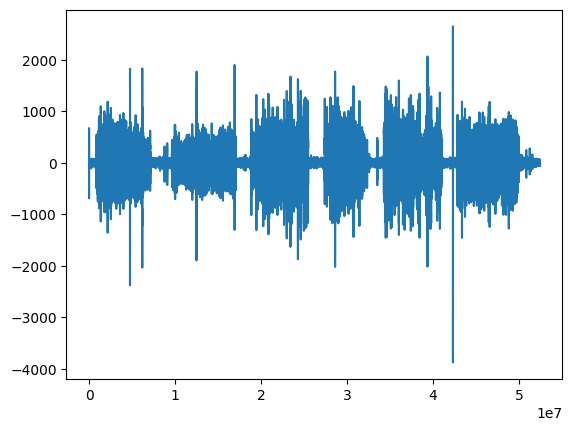

In [4]:
mic_df.int_array.plot()

In [5]:
psycho = pd.read_csv(f'/Users/bryan.gonzalez/CUNY_subs/sub-{subject}/sub-{subject}_task-CUNY_run-001_behavior.csv', sep=',', header=0)
audio_order = [f.split('/')[-1].split('.')[0] for f in psycho.AudioFile.unique() if pd.notna(f)]
audio_file_path = '../../NEW_AUDIO_48/'+ audio_order[0] + '.wav'
fs_audiofile, audiofile = wavfile.read(audio_file_path)
audio_duration = len(audiofile) / fs_audiofile
# downsample the audio file to 441.1kHz
audiofile = resample(audiofile, int(audio_duration * 44100))
# downsample the audio file to 10kHz
#audiofile = resample(audiofile, int(audio_duration * 10000))


In [6]:
# Normalize both arrays
def normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-8)


In [7]:
mic = normalize(mic_df.int_array.values)
audio = normalize(audiofile)

In [17]:
[i for i in range(0,len(mic)+len(audio)-1 , 44100)]

[0,
 44100,
 88200,
 132300,
 176400,
 220500,
 264600,
 308700,
 352800,
 396900,
 441000,
 485100,
 529200,
 573300,
 617400,
 661500,
 705600,
 749700,
 793800,
 837900,
 882000,
 926100,
 970200,
 1014300,
 1058400,
 1102500,
 1146600,
 1190700,
 1234800,
 1278900,
 1323000,
 1367100,
 1411200,
 1455300,
 1499400,
 1543500,
 1587600,
 1631700,
 1675800,
 1719900,
 1764000,
 1808100,
 1852200,
 1896300,
 1940400,
 1984500,
 2028600,
 2072700,
 2116800,
 2160900,
 2205000,
 2249100,
 2293200,
 2337300,
 2381400,
 2425500,
 2469600,
 2513700,
 2557800,
 2601900,
 2646000,
 2690100,
 2734200,
 2778300,
 2822400,
 2866500,
 2910600,
 2954700,
 2998800,
 3042900,
 3087000,
 3131100,
 3175200,
 3219300,
 3263400,
 3307500,
 3351600,
 3395700,
 3439800,
 3483900,
 3528000,
 3572100,
 3616200,
 3660300,
 3704400,
 3748500,
 3792600,
 3836700,
 3880800,
 3924900,
 3969000,
 4013100,
 4057200,
 4101300,
 4145400,
 4189500,
 4233600,
 4277700,
 4321800,
 4365900,
 4410000,
 4454100,
 4498200,


In [20]:
corrs = []
for i in tqdm(range(0,len(mic)+len(audio)-44100 , 44100)):
    m= mic[i:i+len(audio)]
    corrs.append(np.corrcoef(m, audio)[0, 1])
    

 81%|████████  | 1065/1312 [00:24<00:05, 43.00it/s]


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 5444140 and the array at index 1 has size 5483608

In [21]:
max(corrs)

np.float64(0.009627480822821912)